In [26]:
import numpy as np
import matplotlib.pyplot as plt

class SimplePDE:
  """
  Solve simple diffusion problem on [0,1] using P1 finite elements.
  """

  def __init__(self, N):
    self.N = N

  def matrix(self, coeff):
    """
    Assemble components of matrix.
    """

    if len(coeff) != 2:
      raise Exception(f"Wrong number of matrix components ({len(coeff)} != 2).")

    # diffusion component
    [nx, I] = np.shape(coeff[0])
    a = coeff[0][:,:]
    A0 = []
    for i in range(I):        
      # assemble A, a piecewise constant on grid
      # linearly dependent on a
      Ai = np.zeros((self.N+1,self.N+1))
      Ai.flat[self.N+2::self.N+2] = (a[1:,i] + a[:-1, i]) * self.N # set diag
      Ai.flat[1::self.N+2] = -a[:,i] * self.N # set first upper diag
      Ai.flat[self.N+1::self.N+2] = -a[:,i] * self.N # set first lower diag
      Ai[[0,-1]] = 0 # for dirichlet boundary
      A0.append(Ai)

    # convection component
    # [nx, I] = np.shape(coeff[1])
    # v = coeff[1][0,:]
    # # v= np.zeros_like(v)
    # A1 = []
    # for i in range(I):
    #   # linearly dependent on v
    #   Ai = np.zeros((self.N+1,self.N+1))
    #   Ai.flat[1::self.N+2] = v[i]# set first upper diag
    #   Ai.flat[self.N+1::self.N+2] = -v[i] # set first lower diag
    #   Ai[[0,-1]] = 0 # for dirichlet boundary
    #   A1.append(Ai)

    # constant part (from boundary)
    [nx, I] = np.shape(coeff[1])
    A2 = []
    for i in range(I):
      # constant part of matrix
      Ai = np.zeros((self.N+1,self.N+1))
      Ai[0,0] = 1
      Ai[-1,-1] = 1
      A2.append(Ai)

    return [A0, A2]
  
  def rhs(self, coeff):
    """
    Assemble components of rhs.
    """

    if len(coeff) != 1:
      raise Exception(f"Wrong number of rhs components ({len(coeff)} != 1).")
    
    [nx, I] = np.shape(coeff[0])
    
    # constant rhs
    F0 = []
    for i in range(I):
      # constant part of rhs
      Fi = np.full((self.N+1,1), 10/(self.N)) # assume RHS = 1 
      Fi[[0,-1]] = 0 # boundary condition
      F0.append(Fi)

    return [F0]

  def solve(self, coeff):
    """
    Assemble and solve FE problem for coeff.
    """
    I = np.shape(coeff[0][0])[1]
    
    U = []

    for i in range(I):
      A = self.matrix([coeff[0][k][:,i, np.newaxis] for k in range(len(coeff[0]))])
      b = self.rhs([coeff[1][k][:,i, np.newaxis] for k in range(len(coeff[1]))])
      U.append(np.linalg.solve(A[0][0] + A[1][0], b[0][0]).reshape((-1,1)))
    
    return U

class diffusion_coeff:

  def __init__(self, Nx, Ny, offset, var):
    self.Nx = Nx
    self.Ny = Ny
    self.offset = offset
    self.var = var

  def __call__(self, X):
    c = np.full(len(X), self.offset,dtype=float)
    for i, x in enumerate(X):
      k = np.arange(1,len(x)-1)
      c[i] += np.sum(k**-2. * np.sin(np.pi*k*x[0]/(self.Nx-1)) \
                      * (x[k]/(self.Ny-1) - 0.5) * self.var)
      # c[i] += np.sum(k**-2. * np.sin(np.pi*k*x[0]/(self.Nx-1)) \
                      # * (x[k+1]/(self.Ny-1) - 0.5) * self.var)
    return np.exp(c)

### PDE test

Solve the PDE using P1 finite elements for a random parameter

Text(0, 0.5, 'A')

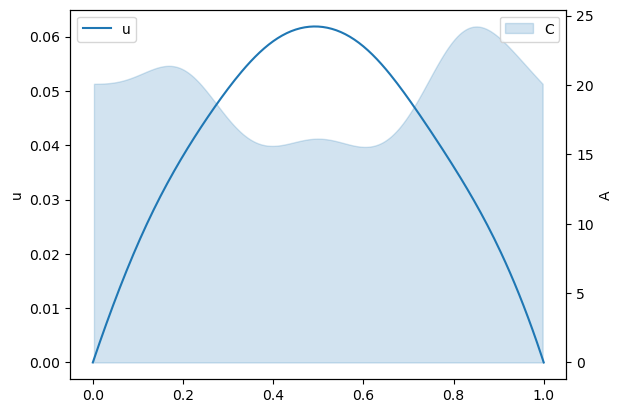

In [27]:
Nx = 200    # spatial resolution
Ny = 5       # parameter resolution
n_a_param = 8 # number of parameters for diffusion coeff
n_param = n_a_param 
offset = 3   # parameter mean
var = 4       # 'variance' of the parameters
v_min, v_max = -10, 10

# get random params
rng = np.random.default_rng()
y = rng.uniform(0, Ny-1, n_a_param)
v = rng.uniform(v_min, v_max)
# X = np.hstack([np.arange(Nx).reshape((-1,1)), np.zeros((Nx,1)), np.tile(y, [Nx,1])])
X = np.hstack([np.arange(Nx).reshape((-1,1)), np.tile(y, [Nx,1])])

cfun = diffusion_coeff(Nx, Ny, offset, var)

C_true = cfun(X)

PDE_fun = SimplePDE(Nx)

U = PDE_fun.solve([[C_true.reshape(-1,1), np.ones((1,1))], [np.ones((1,1))]])
# U = PDE_fun.solve([[C_true.reshape(-1,1), v * np.ones((1,1)), np.ones((1,1))], [np.ones((1,1))]])
U = np.ravel(U[0])

fig, ax = plt.subplots()
ax2 = ax.twinx()

x = np.arange(Nx+1) / Nx
midpoints = (np.arange(Nx) + 0.5) / Nx
p = ax.plot(x, U, label='u')
ax2.fill_between((np.arange(len(C_true)) + 0.5) / (len(C_true)), C_true, alpha=0.2, color=p[0].get_color(), label='C')

ax.set_ylabel('u')
ax.legend(loc='upper left')
ax2.legend(loc='upper right')
ax2.set_ylabel('A')

### Get HT approx of coefficient

In [28]:
from tree import Tree
from tree_tensor import TreeBasedTensor
from tree_cross import TreeCross
from tree_util import balanced_binary_tupletree, linear_tupletree

tol = 1e-3
param_shape = tuple([Ny] * n_param)

tree = Tree.from_tupletree(balanced_binary_tupletree(n_param))
# tree = Tree.from_tupletree((0,(1,2)))
tree.print()
C_a = TreeBasedTensor.randn(tree, (Nx,) + param_shape, Ny)

cross = TreeCross(C_a)
cross.run(cfun, n_iter=50, eps=tol, kickrank=1, verbose=True)
C_a.round(tol=tol)
C_a.print()
# # random init tensor
# C_a = tt.rand(np.array([Nx] + [Ny] * n_param),r=3)
# # compute TT approx using TT-cross
# C_a = tt.cross.rect_cross.cross(cfun, C_a, eps = 1e-8, kickrank=1)
# C_a = C_a.round(1e-12)

[16] (root) 
 + [0] (dim 0)
 + [15] 
    + [7] 
    |  + [3] 
    |  |  + [1] (dim 1)
    |  |  + [2] (dim 2)
    |  + [6] 
    |     + [4] (dim 3)
    |     + [5] (dim 4)
    + [14] 
       + [10] 
       |  + [8] (dim 5)
       |  + [9] (dim 6)
       + [13] 
          + [11] (dim 7)
          + [12] (dim 8)

swp:  1/50 f_evals=1546 self.max_dx=6.48e+06
swp:  2/50 f_evals=3634 self.max_dx=7.55e+01
swp:  3/50 f_evals=7077 self.max_dx=2.24e+01
swp:  4/50 f_evals=12543 self.max_dx=7.53e+00
swp:  5/50 f_evals=21392 self.max_dx=2.43e+00
swp:  6/50 f_evals=33570 self.max_dx=6.06e-01
swp:  7/50 f_evals=46052 self.max_dx=3.48e-02
swp:  8/50 f_evals=59231 self.max_dx=2.34e-02
swp:  9/50 f_evals=71521 self.max_dx=1.25e-02
swp: 10/50 f_evals=84631 self.max_dx=1.47e-02
swp: 11/50 f_evals=97365 self.max_dx=1.15e-02
swp: 12/50 f_evals=110405 self.max_dx=1.29e-02
swp: 13/50 f_evals=123445 self.max_dx=1.37e-02
swp: 14/50 f_evals=136897 self.max_dx=1.51e-02
swp: 15/50 f_evals=149653 self.max_dx=1.76e

### Test TT approx

Compare TT approx of coefficient $A$ vs the true coefficient $A$ for the random parameter sample from above

RMS l2 err = 5.94e-02


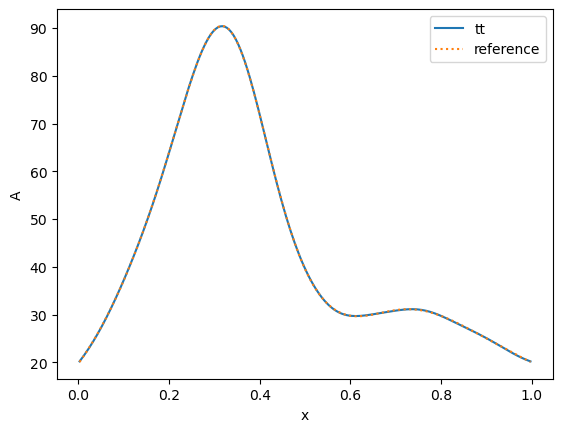

In [29]:
N_MC = 500

def RMS(x, **kwargs):
  return np.sqrt(np.mean(np.square(x), **kwargs))

errs = np.zeros(N_MC)
for i in range(N_MC):
  # eval TT-approx of coeff
  y = rng.integers(0, Ny, n_a_param)
  C_eval = np.ravel(C_a[:, *y])

  X = np.hstack([np.arange(Nx).reshape((-1,1)), np.tile(y, [Nx,1])])
  # X = np.hstack([np.arange(Nx).reshape((-1,1)), np.zeros((Nx,1)), np.tile(y, [Nx,1])])
  C_true = cfun(X)

  errs[i] = RMS(C_eval-C_true)

print(f'RMS l2 err = {RMS(errs):.2e}')

fig, ax = plt.subplots()

x = (np.arange(0, Nx) + .5) / Nx
ax.plot(x, C_eval, label='tt')
ax.plot(x, C_true, ls='dotted', label="reference")
ax.set_xlabel('x')
ax.set_ylabel('A')
ax.legend()

In [30]:
# tensor for convection
C_v = TreeBasedTensor.ones(tree, (1,) + param_shape)
C_v.cores[C_v.tree.dim2leaf(1)] = np.linspace(v_min,v_max, Ny).reshape(-1,1)
C_v.cores[C_v.tree.dim2leaf(1)] = np.zeros(Ny).reshape(-1,1)

# helper tensor that is constant 1
C_const = TreeBasedTensor.ones(tree, (1,) + param_shape)
C_const2 = TreeBasedTensor.ones(tree, (1,) + param_shape)

### ALS-cross test

In [ ]:
from tree_als_cross import TreeALSCross
import cProfile

test = TreeALSCross(
  [C_a, C_const],
  [C_const],
  PDE_fun,
  rinit=0,
  verbose=1,
  kickrank=5
  )

stats = cProfile.run('test.run(n_iter=2)', 'profile.prof')
# test.run(n_iter=2)


u = test.get_tensor()

Init finished
= swp=0
= swp=0 finished, max_dx=9.46e+02
= swp=1
= swp=1 finished, max_dx=6.53e-03


In [ ]:
import pstats
from pstats import SortKey
p = pstats.Stats('profile.prof')
p.strip_dirs().sort_stats('cumtime').print_stats()

Tue Aug  4 16:01:35 2026    profile

         516367 function calls (516344 primitive calls) in 193.041 seconds

   Ordered by: cumulative time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
       43    0.002    0.000  214.019    4.977 base_events.py:1966(_run_once)
      2/1    0.000    0.000  193.041  193.041 {built-in method builtins.exec}
        1    0.000    0.000  193.040  193.040 <string>:1(<module>)
        1    0.003    0.003  193.040  193.040 tree_als_cross.py:89(run)
     16/2    0.005    0.000  193.027   96.514 tree_als_cross.py:195(_als_interior_worker)
       43    0.000    0.000  122.128    2.840 selectors.py:435(select)
       43  122.127    2.840  122.127    2.840 {method 'poll' of 'select.epoll' objects}
      744    0.004    0.000   70.818    0.095 einsumfunc.py:1244(einsum)
     3264   70.722    0.022   70.722    0.022 {built-in method numpy._core._multiarray_umath.c_einsum}
      712    0.011    0.000    0.070    0.000 einsumfunc.py:634(

### Test ALS-cross accuracy

Compare ALS cross approximation vs PDE solution for a random sample

In [33]:
N_MC = 500
err = 0
err_c = 0

for n in range(N_MC):
  # get random parameter
  y = rng.integers(0, Ny, n_param)
  X = np.hstack([np.arange(Nx).reshape((-1,1)), np.tile(y, [Nx,1])])

  C_a_true = cfun(X) # compute true coeff
  v_true = np.linspace(v_min,v_max,Ny)[y[0]]
  v_true=0

  U = PDE_fun.solve([[C_a_true.reshape(-1,1), np.zeros((1,1))], [np.zeros((1,1))]]) # solve PDE
  U = np.ravel(U)

  # eval ALS-cross
  U_eval = np.ravel(u[:, *y])
  err += np.sum(np.square(U - U_eval))

  C_eval = np.ravel(C_a[:, *y[:]])
  U_c = PDE_fun.solve([[C_eval.reshape(-1,1), np.zeros((1,1))], [np.zeros((1,1))]]) # solve PDE
  U_c = np.ravel(U_c)
  err_c += np.sum(np.square(U - U_c))

err = np.sqrt(err / N_MC)
err_c = np.sqrt(err_c / N_MC)

print(f'RMS l2 err = {err:.2e}')
print(f'RMS l2 err with approx coeff = {err_c:.2e}')

RMS l2 err = 1.17e-03
RMS l2 err with approx coeff = 6.45e-04


l2 err = 1.60e-03
l2 err to approx coeff = 1.48e-03


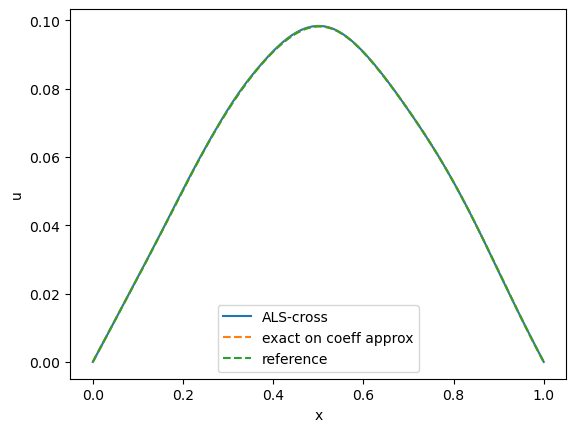

In [34]:
# get random parameter
y = rng.integers(0, Ny, n_param)
X = np.hstack([np.arange(Nx).reshape((-1,1)), np.tile(y, [Nx,1])])

C_a_true = cfun(X) # compute true coeff
v_true = np.linspace(v_min,v_max,Ny)[y[0]]
v_true = 0

U = PDE_fun.solve([[C_a_true.reshape(-1,1), np.zeros((1,1))], [np.zeros((1,1))]]) # solve PDE
U = np.ravel(U)

C_eval = np.ravel(C_a[:, *y[:]])
U_c = PDE_fun.solve([[C_eval.reshape(-1,1), np.zeros((1,1))], [np.zeros((1,1))]]) # solve PDE
U_c = np.ravel(U_c)

# eval ALS-cross
U_eval = np.ravel(u[:, *y])

fig, ax = plt.subplots()

x = np.arange(0, Nx+1) / Nx
ax.plot(x, U_eval, label='ALS-cross')
ax.plot(x, U_c, ls='dashed', label='exact on coeff approx')
ax.plot(x, U, ls='dashed', label='reference')
ax.set_xlabel('x')
ax.set_ylabel('u')
ax.legend()

print(f'l2 err = {np.linalg.norm(U-U_eval):.2e}')
print(f'l2 err to approx coeff = {np.linalg.norm(U_c-U_eval):.2e}')